```
# Deep Quantum Neural Network (DQNN) for MNIST using PennyLane + PyTorch
# Install:
# pip install torch torchvision pennylane tqdm


Classical Neural Network
        ↓
Variational Quantum Circuit (VQC)
        ↓
Classical Classifier
```


---
## Overall Data Flow
```
28×28 Image
      │
      ▼
Flatten (784)
      │
      ▼
Classical Dense Network
784 → 256 → 128 → NUM_QUBITS
      │
      ▼
Quantum Circuit
AngleEmbedding
      │
StronglyEntanglingLayers
      │
Expectation Values (<Zi>)
      │
      ▼
Dense Classifier
NUM_QUBITS → 64 → 10
      │
      ▼
Softmax (via CrossEntropyLoss during training)
      │
      ▼
Predicted Digit (0–9)
```

In [12]:
!pip install pennylane torch torchvision matplotlib scikit-learn seaborn -q ipywidgets --upgrade 

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import pennylane as qml
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import io
import torch
from PIL import Image, ImageOps
import torchvision.transforms as transforms
from ipywidgets import FileUpload, Button, Output, VBox, Label
from IPython.display import display
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight

print("Imports Loaded!!!")

Imports Loaded!!!


In [23]:
# ============================
# Hyperparameters
# ============================
BATCH_SIZE = 32
EPOCHS = 2
LR = 0.001
NUM_QUBITS = 8
NUM_LAYERS = 6

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


# ============================
# Dataset
# ============================
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

train_labels = train_dataset.targets.numpy()
test_labels = test_dataset.targets.numpy()

print("Training class distribution:")
print(Counter(train_labels))

print("\nTesting class distribution:")
print(Counter(test_labels))

# Get training labels
train_labels = train_dataset.targets.numpy()

# Compute balanced class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert to tensor and move to the same device as the model
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print("Class Weights:")
for i, w in enumerate(class_weights):
    print(f"Class {i}: {w:.4f}")

Using device: cpu
Training class distribution:
Counter({np.int64(1): 6742, np.int64(7): 6265, np.int64(3): 6131, np.int64(2): 5958, np.int64(9): 5949, np.int64(0): 5923, np.int64(6): 5918, np.int64(8): 5851, np.int64(4): 5842, np.int64(5): 5421})

Testing class distribution:
Counter({np.int64(1): 1135, np.int64(2): 1032, np.int64(7): 1028, np.int64(3): 1010, np.int64(9): 1009, np.int64(4): 982, np.int64(0): 980, np.int64(8): 974, np.int64(6): 958, np.int64(5): 892})
Class Weights:
Class 0: 1.0130
Class 1: 0.8899
Class 2: 1.0070
Class 3: 0.9786
Class 4: 1.0270
Class 5: 1.1068
Class 6: 1.0139
Class 7: 0.9577
Class 8: 1.0255
Class 9: 1.0086


In [24]:
# ============================
# Quantum Device
# ============================
dev = qml.device("default.qubit", wires=NUM_QUBITS)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):

    qml.AngleEmbedding(inputs, wires=range(NUM_QUBITS))
    qml.StronglyEntanglingLayers(weights, wires=range(NUM_QUBITS))

    return [qml.expval(qml.PauliZ(i)) for i in range(NUM_QUBITS)]

weight_shapes = {
    "weights": (NUM_LAYERS, NUM_QUBITS, 3)
}

quantum_layer = qml.qnn.TorchLayer(
    quantum_circuit,
    weight_shapes
)

# ============================
# Deep Quantum Neural Network
# ============================
class DeepQNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.classical = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, NUM_QUBITS)
        )

        self.quantum = quantum_layer

        self.classifier = nn.Sequential(
            nn.Linear(NUM_QUBITS, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):

        x = x.view(x.size(0), -1)

        x = self.classical(x)

        x = self.quantum(x)

        x = self.classifier(x)

        return x

model = DeepQNN().to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# ============================
# Training
# ============================
print("\nStarting Training...\n")

# ============================
# Training + Validation
# ============================

train_acc_history = []
val_acc_history = []
train_loss_history = []
val_loss_history = []

for epoch in range(EPOCHS):

    ########################
    # TRAIN
    ########################
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    train_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS} [Train]",
        leave=False
    )

    for images, labels in train_bar:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

        train_bar.set_postfix(
            Loss=f"{train_loss/(train_total/BATCH_SIZE):.4f}",
            Acc=f"{100*train_correct/train_total:.2f}%"
        )

    train_loss /= len(train_loader)
    train_acc = 100 * train_correct / train_total

    ########################
    # VALIDATION
    ########################
    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    val_bar = tqdm(
        test_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS} [Val]",
        leave=False
    )

    with torch.no_grad():

        for images, labels in val_bar:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

            val_bar.set_postfix(
                Loss=f"{val_loss/(val_total/BATCH_SIZE):.4f}",
                Acc=f"{100*val_correct/val_total:.2f}%"
            )

    val_loss /= len(test_loader)
    val_acc = 100 * val_correct / val_total

    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

# ============================
# Testing
# ============================
model.eval()

correct = 0
total = 0

test_bar = tqdm(test_loader, desc="Testing")

with torch.no_grad():

    for images, labels in test_bar:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)

        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        test_bar.set_postfix({
            "Acc": f"{100*correct/total:.2f}%"
        })

print(f"\nFinal Test Accuracy: {100*correct/total:.2f}%")

# ============================
# Predict One Sample
# ============================
image, label = test_dataset[0]

model.eval()

with torch.no_grad():

    prediction = model(image.unsqueeze(0).to(DEVICE))
    predicted = prediction.argmax(dim=1).item()

print("\nSample Prediction")
print("-----------------")
print("True Label     :", label)
print("Predicted Label:", predicted)


Starting Training...



Epoch 1/2 [Train]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 1/2 [Val]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch [01/2] | Train Loss: 0.6386 | Train Acc: 84.10% | Val Loss: 0.1861 | Val Acc: 95.89%


Epoch 2/2 [Train]:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 2/2 [Val]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch [02/2] | Train Loss: 0.1375 | Train Acc: 96.68% | Val Loss: 0.1137 | Val Acc: 97.37%


Testing:   0%|          | 0/313 [00:00<?, ?it/s]


Final Test Accuracy: 97.37%

Sample Prediction
-----------------
True Label     : 7
Predicted Label: 7



Classification Report

              precision    recall  f1-score   support

           0     0.9837    0.9847    0.9842       980
           1     0.9947    0.9859    0.9903      1135
           2     0.9816    0.9826    0.9821      1032
           3     0.9711    0.9644    0.9677      1010
           4     0.9706    0.9766    0.9736       982
           5     0.9537    0.9697    0.9616       892
           6     0.9691    0.9823    0.9756       958
           7     0.9656    0.9825    0.9740      1028
           8     0.9797    0.9394    0.9591       974
           9     0.9634    0.9663    0.9649      1009

    accuracy                         0.9737     10000
   macro avg     0.9733    0.9734    0.9733     10000
weighted avg     0.9738    0.9737    0.9737     10000



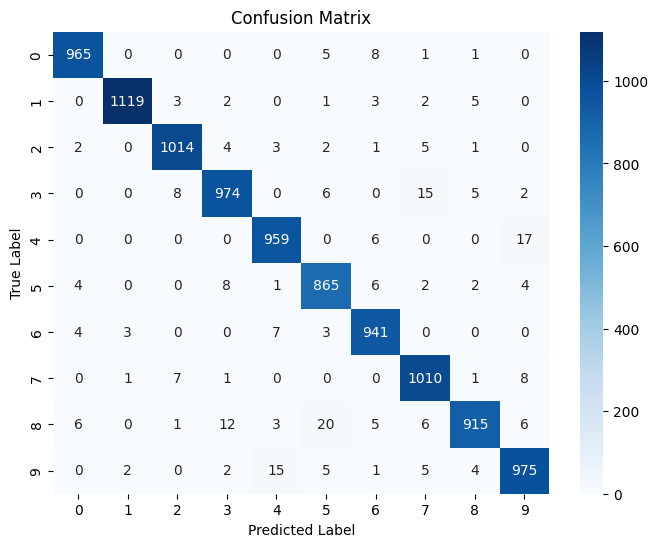

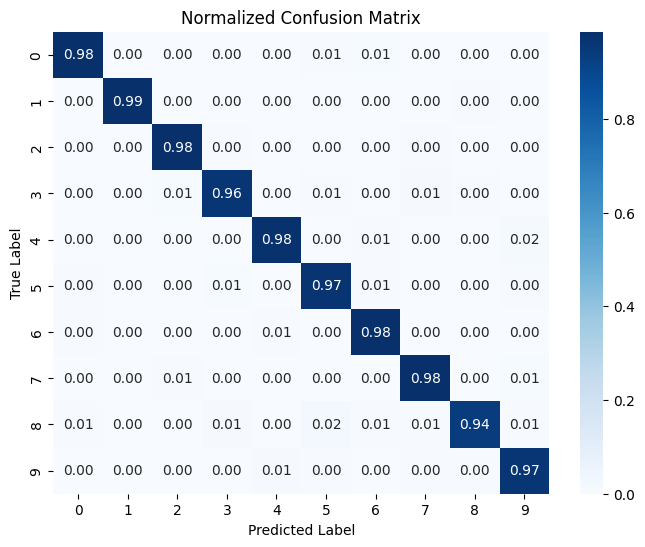

In [25]:
# Evaluation mode
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(DEVICE)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# ============================
# Classification Report
# ============================
print("\nClassification Report\n")
print(classification_report(all_labels, all_preds, digits=4))

# ============================
# Confusion Matrix
# ============================
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=np.arange(10),
    yticklabels=np.arange(10)
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


cm_norm = confusion_matrix(all_labels, all_preds, normalize="true")

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=np.arange(10),
    yticklabels=np.arange(10)
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.show()

In [30]:
# --- Widgets ---
uploader = FileUpload(accept='image/*', multiple=False, description='Upload')
status_label = Label(value="No file uploaded yet.")
predict_button = Button(description="Predict", button_style='success', disabled=True)
upload_output = Output()   # shows the uploaded image
predict_output = Output()  # shows the prediction result

state = {"image": None}

def on_upload_change(change):
    if len(uploader.value) == 0:
        return
    
    uploaded_file = list(uploader.value.values())[0] if isinstance(uploader.value, dict) else uploader.value[0]
    content = uploaded_file["content"]
    if not isinstance(content, (bytes, bytearray)):
        content = content.tobytes()
    
    image = Image.open(io.BytesIO(content)).convert("L")
    image = ImageOps.invert(image)
    image = image.resize((28, 28))
    
    state["image"] = image
    status_label.value = "✅ Upload complete!"
    predict_button.disabled = False
    
    # Show the uploaded image immediately
    upload_output.clear_output()
    with upload_output:
        plt.imshow(image, cmap="gray")
        plt.title("Uploaded Image (processed)")
        plt.axis("off")
        plt.show()

def on_predict_click(b):
    predict_output.clear_output()
    with predict_output:
        if state["image"] is None:
            print("Please upload an image first.")
            return
        
        transform = transforms.Compose([transforms.ToTensor()])
        input_tensor = transform(state["image"]).unsqueeze(0).to(DEVICE)
        
        model.eval()
        with torch.no_grad():
            out = model(input_tensor)
            prediction = out.argmax(dim=1).item()
        
        print("Predicted Digit:", prediction)
        plt.imshow(state["image"], cmap="gray")
        plt.title(f"Predicted: {prediction}")
        plt.axis("off")
        plt.show()

uploader.observe(on_upload_change, names='value')
predict_button.on_click(on_predict_click)

display(VBox([uploader, status_label, upload_output, predict_button, predict_output]))

In [29]:
# --- Widgets ---
uploader = FileUpload(accept='image/*', multiple=False, description='Upload')
status_label = Label(value="No file uploaded yet.")
predict_button = Button(description="Predict", button_style='success', disabled=True)
upload_output = Output()   # shows the uploaded image
predict_output = Output()  # shows the prediction result

state = {"image": None}

def on_upload_change(change):
    if len(uploader.value) == 0:
        return
    
    uploaded_file = list(uploader.value.values())[0] if isinstance(uploader.value, dict) else uploader.value[0]
    content = uploaded_file["content"]
    if not isinstance(content, (bytes, bytearray)):
        content = content.tobytes()
    
    image = Image.open(io.BytesIO(content)).convert("L")
    image = ImageOps.invert(image)
    image = image.resize((28, 28))
    
    state["image"] = image
    status_label.value = "✅ Upload complete!"
    predict_button.disabled = False
    
    # Show the uploaded image immediately
    upload_output.clear_output()
    with upload_output:
        plt.imshow(image, cmap="gray")
        plt.title("Uploaded Image (processed)")
        plt.axis("off")
        plt.show()

def on_predict_click(b):
    predict_output.clear_output()
    with predict_output:
        if state["image"] is None:
            print("Please upload an image first.")
            return
        
        transform = transforms.Compose([transforms.ToTensor()])
        input_tensor = transform(state["image"]).unsqueeze(0).to(DEVICE)
        
        model.eval()
        with torch.no_grad():
            out = model(input_tensor)
            prediction = out.argmax(dim=1).item()
        
        print("Predicted Digit:", prediction)
        plt.imshow(state["image"], cmap="gray")
        plt.title(f"Predicted: {prediction}")
        plt.axis("off")
        plt.show()

uploader.observe(on_upload_change, names='value')
predict_button.on_click(on_predict_click)

display(VBox([uploader, status_label, upload_output, predict_button, predict_output]))

# Summary of Quantum Techniques Used

1. **Qubit-based quantum computation**
2. **Quantum state preparation**
3. **Angle encoding**
4. **Quantum rotation gates**
5. **Variational Quantum Circuit (VQC)**
6. **Parameterized quantum gates**
7. **Quantum entanglement**
8. **Multi-qubit operations**
9. **Quantum feature mapping**
10. **Quantum measurement**
11. **Pauli-Z expectation values**
12. **Hybrid quantum-classical optimization**
13. **Quantum gradient-based learning**